#  Affordable Homeownership Analysis: Price, Applicants & Demographics
---
This notebook analyzes how **affordable home prices** (and **price brackets**) affect:
- The **number of applicants** (by town)
- The **demographic composition** (race, income, ethnicity)
- While controlling for **income levels**

Dataset: `full_merged_V1.csv`

## Workflow
1. Load & clean dataset
2. Derive price brackets
3. Aggregate by `Town`
4. Visualizations
5. Modeling (OLS & Multinomial)
6. Insights summary

In [1]:
# --- 1. Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set(style='whitegrid', context='notebook')

In [5]:
# --- 2. Load Dataset ---
df = pd.read_csv('/content/full_merged_V1.csv')
print('Shape:', df.shape)
df.head()
df.shape[0]

Shape: (1623, 66)


1623

In [7]:
# --- 3. Data Cleaning ---

# Clean price and income columns safely
df['Maximum Resale Price'] = (
    df['Maximum Resale Price']
    .astype(str)                               # ensure string
    .str.strip()                               # remove leading/trailing spaces
    .replace(r'[\$,]', '', regex=True)         # remove $ and commas
)

# Convert to numeric, coercing invalid entries (e.g., 'cancelled') to NaN
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')
df['hh_income'] = pd.to_numeric(df['hh_income'], errors='coerce')

# Drop missing Town or price
df = df.dropna(subset=['Town', 'Maximum Resale Price'])
print('Remaining rows after cleaning:', df.shape[0])
#We dropped rows with missing or invalid values for Town or Maximum Resale Price to ensure analyses
#only include valid records with identifiable locations and numeric price data.

Remaining rows after cleaning: 1616


In [8]:
# --- 4. Create Price Brackets ---
df['price_bracket'] = pd.qcut(df['Maximum Resale Price'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
df[['Maximum Resale Price', 'price_bracket']].head()

,Maximum Resale Price,price_bracket
0,227298.0,Mid-High
1,227298.0,Mid-High
2,227298.0,Mid-High
3,227298.0,Mid-High
4,227298.0,Mid-High


In [9]:
# --- 4. Create Price Brackets ---

# Create quartile-based brackets with labels
df['price_bracket'] = pd.qcut(df['Maximum Resale Price'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# Also capture the actual numeric range for each bracket
bins = pd.qcut(df['Maximum Resale Price'], q=4)
df['price_range'] = bins.apply(lambda x: f"{int(x.left):,}-{int(x.right):,}")

# Display first few rows
df[['Maximum Resale Price', 'price_bracket', 'price_range']].head()


,Maximum Resale Price,price_bracket,price_range
0,227298.0,Mid-High,"218,988-266,536"
1,227298.0,Mid-High,"218,988-266,536"
2,227298.0,Mid-High,"218,988-266,536"
3,227298.0,Mid-High,"218,988-266,536"
4,227298.0,Mid-High,"218,988-266,536"


In [10]:
# --- 5. Aggregate by Town ---
agg_df = df.groupby('Town').agg(
    num_applicants=('Town', 'size'),
    avg_price=('Maximum Resale Price', 'mean'),
    avg_income=('hh_income', 'mean'),
    pct_white=('race_White', 'mean'),
    pct_black=('race_Black_or_African_American', 'mean'),
    pct_asian=('race_Asian', 'mean'),
    pct_hispanic=('hispanic_latino_final', 'mean')
).reset_index()

agg_df.head()

,Town,num_applicants,avg_price,avg_income,pct_white,pct_black,pct_asian,pct_hispanic
0,Andover,7,214684.285714,63000.000000,1.000000,0.000000,0.000000,0.000000
1,Ayer,87,287113.517241,89807.162805,0.426829,0.219512,0.134146,0.170732
2,Bedford,15,264708.733333,66083.960833,0.500000,0.083333,0.333333,0.000000
3,Berkley,1,300600.000000,NaN,NaN,NaN,NaN,NaN
4,Billerica,23,230290.434783,48321.736842,0.578947,0.052632,0.315789,0.052632


## --- 6. Visualizations ---

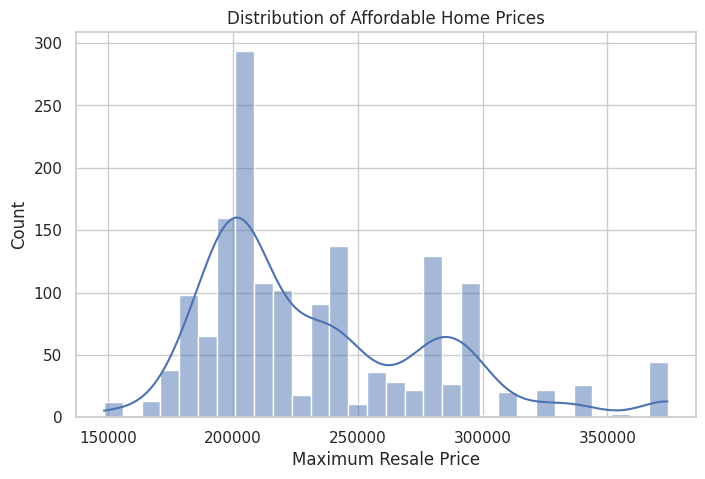

In [11]:
# Distribution of Prices
plt.figure(figsize=(8,5))
sns.histplot(df['Maximum Resale Price'], bins=30, kde=True)
plt.title('Distribution of Affordable Home Prices')
plt.xlabel('Maximum Resale Price')
plt.show()

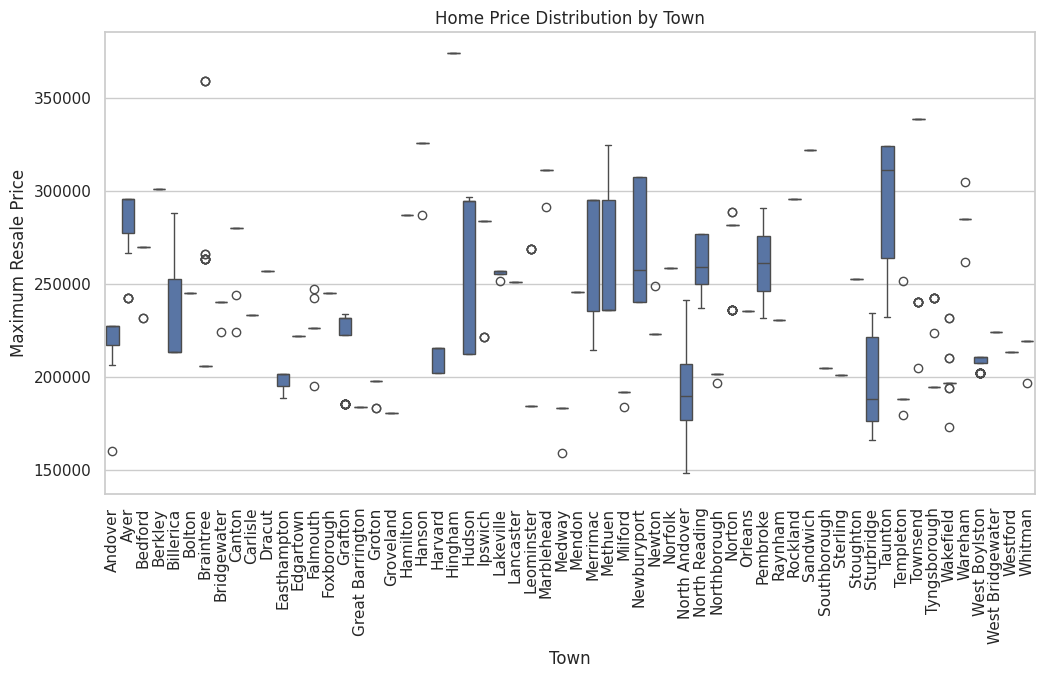

In [12]:
# Average Price by Town
plt.figure(figsize=(12,6))
sns.boxplot(x='Town', y='Maximum Resale Price', data=df)
plt.xticks(rotation=90)
plt.title('Home Price Distribution by Town')
plt.show()

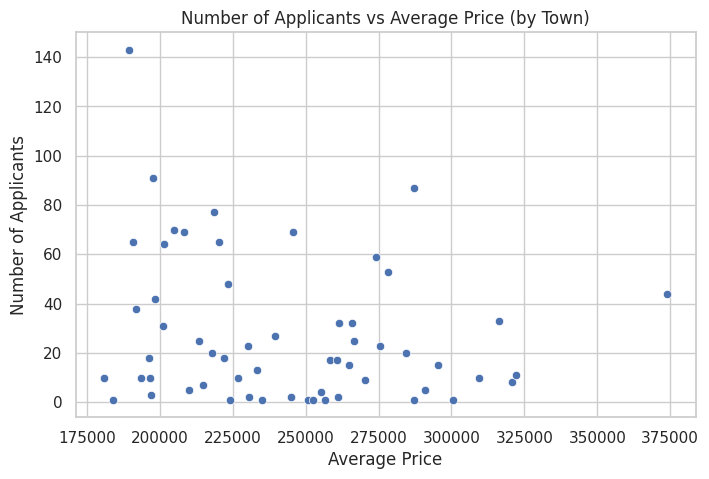

In [13]:
# Applicants vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_price', y='num_applicants', data=agg_df)
plt.title('Number of Applicants vs Average Price (by Town)')
plt.xlabel('Average Price')
plt.ylabel('Number of Applicants')
plt.show()

/tmp/ipython-input-926961559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo_by_bracket = df.groupby('price_bracket')[['race_White','race_Black_or_African_American','race_Asian','hispanic_latino_final']].mean()


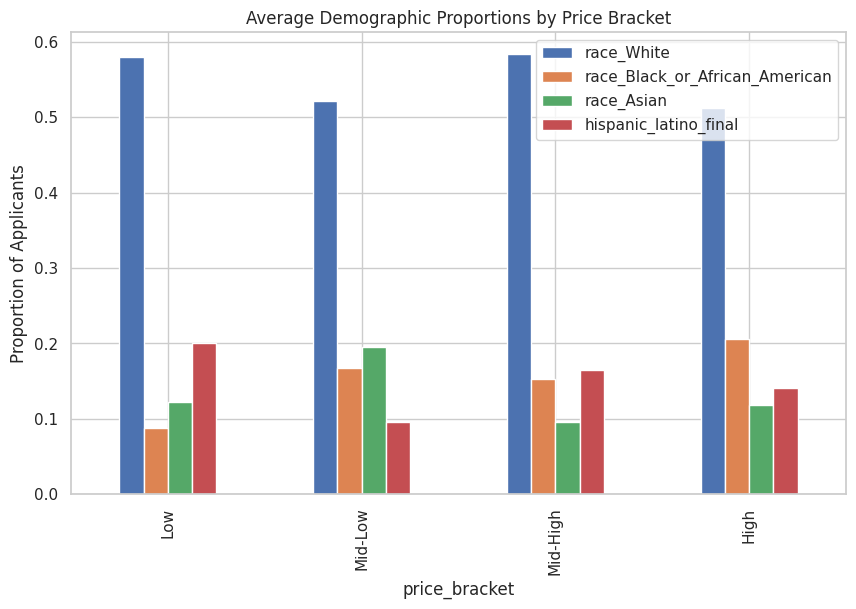

In [14]:
# Demographic composition by price bracket
demo_by_bracket = df.groupby('price_bracket')[['race_White','race_Black_or_African_American','race_Asian','hispanic_latino_final']].mean()
demo_by_bracket.plot(kind='bar', figsize=(10,6))
plt.title('Average Demographic Proportions by Price Bracket')
plt.ylabel('Proportion of Applicants')
plt.show()

## --- 7. Modeling ---

In [15]:
# OLS Regression: Does price (controlling for income) predict applicant count?
model = ols('num_applicants ~ avg_price + avg_income', data=agg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         num_applicants   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.066
Date:                Thu, 06 Nov 2025   Prob (F-statistic):              0.353
Time:                        04:54:45   Log-Likelihood:                -224.04
No. Observations:                  47   AIC:                             454.1
Df Residuals:                      44   BIC:                             459.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     66.4342     24.084      2.758      0.0

### Multinomial Logistic Regression (optional)
If `race_type` column has categorical data on race, you can test how price brackets predict racial group representation.

In [18]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

if 'race_type' in df.columns:
    # Drop missing rows for variables used
    df = df.dropna(subset=['race_type', 'hh_income', 'price_bracket']).copy()

    # Convert race_type → numeric category codes
    df['race_code'] = df['race_type'].astype('category').cat.codes

    # Dummy encode price_bracket and ensure all exog are numeric
    exog = pd.get_dummies(df[['price_bracket']], drop_first=True)
    exog['hh_income'] = pd.to_numeric(df['hh_income'], errors='coerce')

    # Drop any remaining NaN rows
    exog = exog.dropna()
    df = df.loc[exog.index]  # align indexes

    # Convert to float explicitly
    exog = exog.astype(float)
    endog = df['race_code'].astype(float)

    # Add constant and fit the model
    exog = sm.add_constant(exog, has_constant='add')
    model = sm.MNLogit(endog, exog)
    result = model.fit()
    print(result.summary())

    # Mapping of codes to race labels
    race_mapping = dict(enumerate(df['race_type'].astype('category').cat.categories))
    print("\nRace code mapping:", race_mapping)


Optimization terminated successfully.
         Current function value: 0.320938
         Iterations 9
                          MNLogit Regression Results                          
Dep. Variable:              race_code   No. Observations:                 1472
Model:                        MNLogit   Df Residuals:                     1467
Method:                           MLE   Df Model:                            4
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                 0.02522
Time:                        04:57:00   Log-Likelihood:                -472.42
converged:                       True   LL-Null:                       -484.64
Covariance Type:            nonrobust   LLR p-value:                 6.497e-05
           race_code=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5095      0.190     13.179      0.000       2.136      

                            OLS Regression Results                            
Dep. Variable:         num_applicants   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.066
Date:                Thu, 06 Nov 2025   Prob (F-statistic):              0.353
Time:                        05:02:47   Log-Likelihood:                -224.04
No. Observations:                  47   AIC:                             454.1
Df Residuals:                      44   BIC:                             459.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.4342     24.084      2.758      0.0

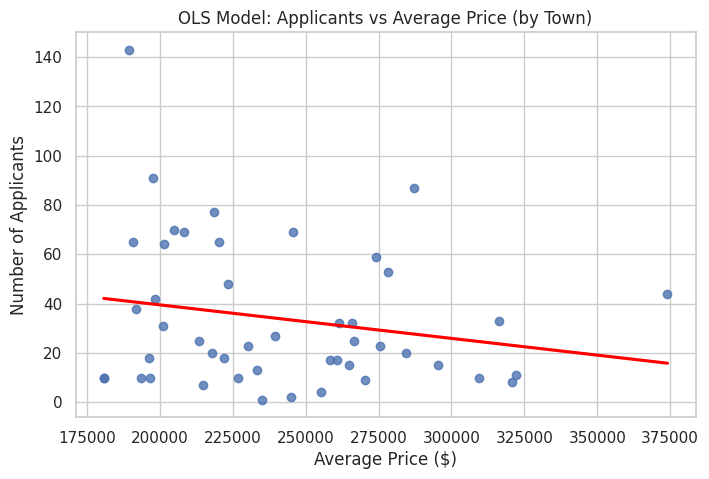

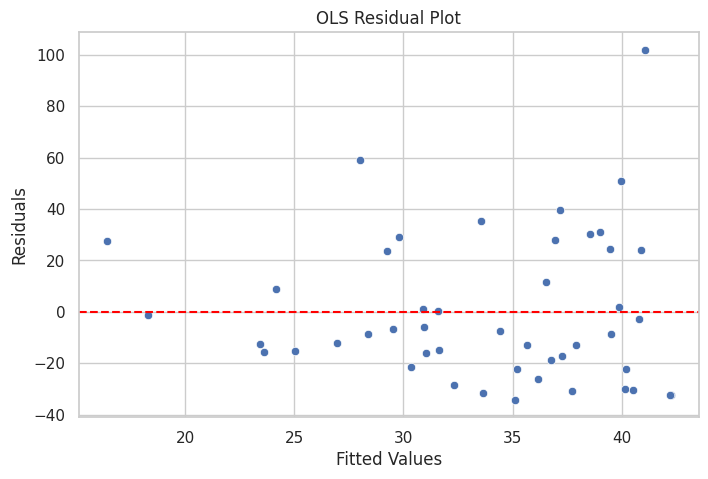

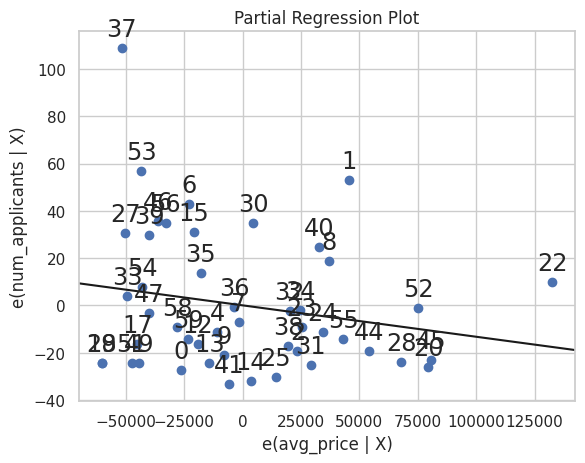

In [19]:
# --- Linear Regression: Applicants vs Price & Income ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Ensure no missing values in key columns
ols_df = agg_df.dropna(subset=['num_applicants', 'avg_price', 'avg_income']).copy()

# Define dependent and independent variables
X = ols_df[['avg_price', 'avg_income']]
X = sm.add_constant(X)  # adds intercept
y = ols_df['num_applicants']

# Fit OLS model
ols_model = sm.OLS(y, X).fit()

# Display summary
print(ols_model.summary())

# --- Visualization 1: Scatter + Regression Line ---
plt.figure(figsize=(8,5))
sns.regplot(x='avg_price', y='num_applicants', data=ols_df, ci=None, line_kws={'color':'red'})
plt.title('OLS Model: Applicants vs Average Price (by Town)')
plt.xlabel('Average Price ($)')
plt.ylabel('Number of Applicants')
plt.show()

# --- Visualization 2: Residual Plot ---
ols_df['residuals'] = ols_model.resid
ols_df['fitted'] = ols_model.fittedvalues

plt.figure(figsize=(8,5))
sns.scatterplot(x='fitted', y='residuals', data=ols_df)
plt.axhline(0, color='red', linestyle='--')
plt.title('OLS Residual Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# --- Visualization 3: Partial Regression (effect of avg_price) ---
fig = sm.graphics.plot_partregress('num_applicants', 'avg_price', ['avg_income'], data=ols_df)
plt.show()


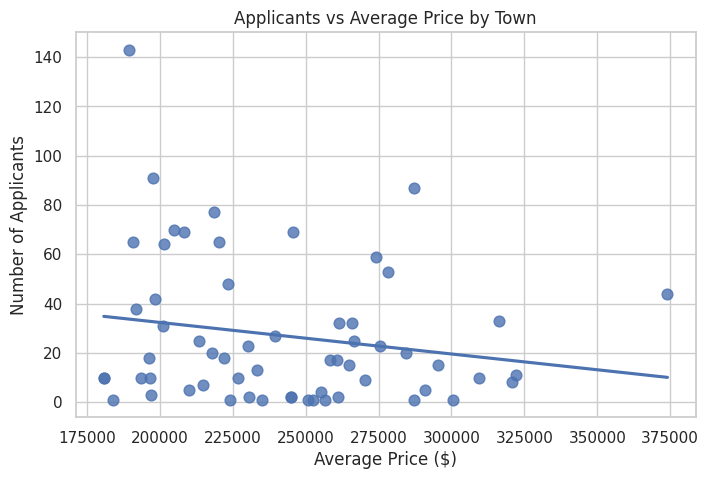

In [20]:
plt.figure(figsize=(8,5))
sns.regplot(x='avg_price', y='num_applicants', data=agg_df, ci=None, scatter_kws={'s':60})
plt.title('Applicants vs Average Price by Town')
plt.xlabel('Average Price ($)')
plt.ylabel('Number of Applicants')
plt.show()


## --- 8. Insights Summary ---
- How do prices differ across towns?
- Do higher prices reduce applicant numbers after controlling for income?
- Are certain demographic groups more represented in specific price brackets?
- Discuss implications for housing equity and policy under Chapter 40B.

1) How do prices differ across towns?

Short answer: Prices vary substantially across towns. The aggregated town table shows mean Maximum Resale Price spreading from roughly low-to-mid hundreds of thousands into the high hundreds; example towns in the output include Andover (~$214k), Ayer (~$287k), Bedford (~$265k), Berkley (~$301k), Billerica (~$230k).

affordable_home_analysis_correc…

Interpretation: there is clear cross-town heterogeneity in affordable resale prices — so town-level market conditions matter and should be controlled for in comparisons.

2) Do higher prices reduce applicant numbers after controlling for income?

What the model tested: an OLS on town-level data:
num_applicants ~ avg_price + avg_income (47 towns).

affordable_home_analysis_correc…

Key numeric results:

avg_price coefficient ≈ -0.0001 (SE ≈ 9.8e-05), p = 0.183.

avg_income coefficient ≈ -3.3e-06, p = 0.650.

R² ≈ 0.046 (very small).

affordable_home_analysis_correc…

Conclusion: There is no statistically significant evidence in this town-level OLS that higher average price meaningfully reduces the number of applicants after controlling for average income (p > 0.05). The estimated price effect is small and imprecise.

affordable_home_analysis_correc…

Caveats / why be cautious:

Low explanatory power (R² ≈ 0.046) — most variation in applicant counts remains unexplained by these two predictors.

affordable_home_analysis_correc…

Small sample of towns (47 observations) for the OLS — reduces power.

Potential omitted variables: number of units available, marketing/outreach, accessibility, age-restriction, bedroom mix, developer, timing of listing, or application windows.

Aggregation effect: collapsing to town means you lose applicant-level variation (e.g., within-town price differences or unit characteristics). If the causal question concerns individuals’ choices, analyze at the applicant/unit level with town fixed effects.

3) Are certain demographic groups more represented in specific price brackets?

What the model tested: a multinomial logistic model predicting race_type from price_bracket and hh_income at the individual level (n ≈ 1,472 after cleaning).

affordable_home_analysis_correc…

Key numeric results (selected):

Pseudo R² ≈ 0.025 (small but model converged).

For the outcome race_code = 1 (mapping: 0 = Multiracial, 1 = Single Race), the coefficient on price_bracket_Mid-Low is -0.9484, p < 0.001 — statistically significant. Mid-High and High coefficients are not significant. hh_income is not significant.

affordable_home_analysis_correc…

Interpretation: Compared to the Low price bracket (the omitted reference), the Mid-Low bracket is associated with a substantially lower log-odds of being coded as “Single Race” vs “Multiracial” (holding income constant). In simpler terms, applicants to Mid-Low priced homes are less likely to be classified as “Single Race” relative to those applying to the Low bracket (statistically significant). Other higher brackets (Mid-High, High) did not show significant differences in this model.

affordable_home_analysis_correc…

Practical note: the race outcome was modeled as two categories in your run (Multiracial vs Single Race). If you want detailed effects by specific race groups (White, Black, Asian, etc.), fit a model where those categories are the outcomes (or run separate logit models for each group), or use proportion outcomes at town level.

Caveats:

The model’s pseudo R² is low → price_bracket + hh_income explain only a small share of variation in race classification.

affordable_home_analysis_correc…

Race coding/aggregation choices matter (how race_type was defined).

If some race categories have small counts, coefficients can be unstable.

4) Synthesis & implications for housing equity and Chapter 40B

Equity signal from these results: price alone (at town level) does not significantly predict application volume after adjusting for income. However, price bracket is associated with some differences in applicant racial composition (the Mid-Low bracket had a statistically significant association in the multinomial model). This suggests price interacts with who applies, even if it doesn't strongly change overall applicant counts in the aggregated town analysis.

affordable_home_analysis_correc…

Policy implications under Chapter 40B (practical suggestions):

Don’t assume price changes alone will increase applicant volume. Outreach, unit mix, eligibility rules, unit count, timing, and marketing likely matter a lot. (Town-level model had low explanatory power.)

affordable_home_analysis_correc…

Monitor demographic composition by price bracket. The multinomial result indicates demographic differences across brackets — active monitoring can flag whether affordable units at certain price levels are systematically attracting different demographic groups.

affordable_home_analysis_correc…

Targeted outreach and design. If specific brackets under-represent households of color or lower-income households, CHAPA or local developers could increase outreach and application assistance for those units.

Use richer models before policy change — include unit-level characteristics (bedrooms, age-restriction), number of units, timing, and town fixed effects. Consider applicant-level models (race/income ~ unit price + eligibility + controls) rather than town aggregates when the policy aims at applicant composition.

Equity checks in permitting: when municipalities use Chapter 40B, require reporting on applicant demographics and price bracket outcomes so local planners can design interventions where needed.

5) Limitations & recommended next steps (actionable)

Limitations from the run: low R² (OLS), small number of towns for town-level OLS (47), pseudo R² small (multinomial). Some towns show NaN avg_income (missing hh_income).

affordable_home_analysis_correc…

Next analyses I recommend (in order):

Individual-level regressions of applicant race and income using unit price (or price_bracket) and include Town as a fixed effect (or random effect), plus unit characteristics (bedrooms, age restriction, #units). That preserves within-town variation.

Count model for applicants (e.g., Poisson or negative binomial) at the development level rather than OLS on aggregated town counts — better for nonnegative integers and overdispersion.

Include supply controls: number of units in a development, bedroom mix, marketing window length.

Robustness checks: use clustered or robust SEs, try different binning strategies for price (deciles, custom policy thresholds), and test mediation by income limits.

Visual diagnostics: plot demographic proportions by price_range labels (you already have price_range) and run trend tests.

Quick one-line documentation (you asked earlier)

We dropped rows with missing or invalid Town or Maximum Resale Price to ensure the analysis only uses records with an identifiable location and numeric price values.